
Testing OpenAI Connection...

AI routing refers to the application of artificial intelligence techniques to optimize the routing of data, goods, or services. This can apply to various fields, including telecommunications, logistics, transportation, and computer networks. Here are some key aspects of AI routing:

1. **Data Routing**: In computer networks, AI can be used to determine the most efficient path for data packets to travel across a network. This can involve analyzing network traffic, latency, and bandwidth to make real-time routing decisions.

2. **Logistics and Supply Chain**: AI routing can optimize delivery routes for logistics companies. By analyzing various factors such as traffic conditions, weather, delivery windows, and vehicle capacities, AI can suggest the most efficient routes to minimize costs and improve delivery times.

3. **Transportation**: In the context of ride-sharing or public transport, AI can analyze demand patterns and traffic conditions to optimize rou

/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


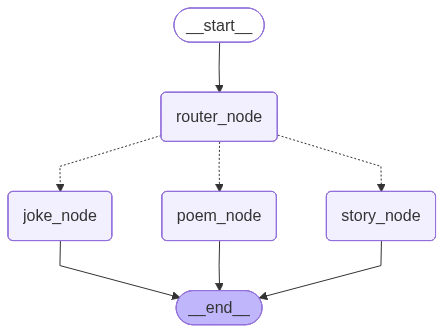



RUNNING ROUTING WORKFLOW

--- ROUTER NODE RUNNING ---

User Input:


    Write me a 3-line story
    about AI taking jobs
    

Routing Decision:

story

--- ROUTING LOGIC ---
Decision: story

--- STORY NODE RUNNING ---

Story Generated:

In a world where AI orchestrated every task, Sarah stood in an empty factory, clutching her resignation letter, the echoes of her colleagues' laughter replaced by silence. As she watched the robots assemble dreams she once nurtured, a tear fell for the humanity lost in progress. In that moment, she vowed to reclaim her voice, even if it meant starting from scratch.


FINAL GENERATED OUTPUT
In a world where AI orchestrated every task, Sarah stood in an empty factory, clutching her resignation letter, the echoes of her colleagues' laughter replaced by silence. As she watched the robots assemble dreams she once nurtured, a tear fell for the humanity lost in progress. In that moment, she vowed to reclaim her voice, even if it meant starting from scratch

In [1]:
"""
====================================================================
LANGGRAPH ROUTING WORKFLOW
====================================================================

CONCEPTS TAUGHT:
----------------
1. Dynamic Routing
2. Conditional Edges
3. Adaptive Workflows
4. LLM-Based Decision Making
5. Structured Outputs
6. Stateful Graph Execution
7. Router Architectures
8. Multi-Branch Workflows
9. Conditional Logic
10. Workflow Orchestration
11. Intent Classification
12. Enterprise AI Routing
13. Observability & Streaming
14. Shared Graph State
15. Intelligent Workflow Navigation

WHAT IS ROUTING?
----------------
Routing allows workflows to dynamically decide:
"What should happen next?"

Instead of fixed execution:

    A → B → C

Routing enables adaptive execution:

              → Story Node →
            /
Input → Router
            \
              → Joke Node →
              → Poem Node →

WHY ROUTING MATTERS:
--------------------
Real AI systems must adapt dynamically based on:
- user intent
- intermediate outputs
- confidence scores
- business rules
- tool availability

Routing enables:
- intelligent branching
- adaptive execution
- modular workflows
- scalable architectures

KEY LANGGRAPH FEATURE:
----------------------
add_conditional_edges()

This allows:
- dynamic branching
- condition-based execution
- intelligent orchestration

ARCHITECTURE TYPE:
------------------
LLM Router Architecture

WORKFLOW:
---------
User Input
      ↓
Router Node
      ↓
Decision:
    - story
    - joke
    - poem
      ↓
Selected Specialized Node
      ↓
Final Output

IMPORTANT CONCEPT:
------------------
Routing separates:
- decision making
FROM
- task execution

This is foundational for:
- multi-agent systems
- enterprise orchestration
- supervisor architectures

"""

# ==============================================================
# STEP 1 — IMPORTS
# ==============================================================

import os

from dotenv import load_dotenv

# ==============================================================
# STEP 2 — LOAD ENV VARIABLES
# ==============================================================

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):

    raise ValueError(
        "OPENAI_API_KEY missing in .env file"
    )

os.environ["OPENAI_API_KEY"] = os.getenv(
    "OPENAI_API_KEY"
)

# Optional LangSmith tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv(
    "LANGCHAIN_PROJECT",
    "LangGraph-Routing"
)

os.environ["LANGCHAIN_TRACING_V2"] = os.getenv(
    "LANGCHAIN_TRACING_V2",
    "true"
)

os.environ["LANGCHAIN_API_KEY"] = os.getenv(
    "LANGCHAIN_API_KEY",
    ""
)

# ==============================================================
# STEP 3 — CREATE OPENAI LLM
# ==============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)

# ==============================================================
# STEP 4 — TEST LLM CONNECTION
# ==============================================================

print("\nTesting OpenAI Connection...\n")

try:

    result = llm.invoke(
        "What is AI Routing?"
    )

    print(result.content)

except Exception as e:

    print("LLM Connection Error:", e)

# ==============================================================
# STEP 5 — STRUCTURED OUTPUTS
# ==============================================================
# IMPORTANT CONCEPT:
#
# Structured outputs create:
# - reliable routing
# - predictable branching
# - safer workflows
#
# MUCH better than:
# - regex parsing
# - string matching
# - fragile conditions

from typing_extensions import Literal

from pydantic import (
    BaseModel,
    Field
)

# ==============================================================
# ROUTING SCHEMA
# ==============================================================
# Router must choose:
# - story
# - joke
# - poem

class Route(BaseModel):

    step: Literal[
        "story",
        "joke",
        "poem"
    ] = Field(

        description=
        """
        Decide which content type
        best matches user request.
        """
    )

# ==============================================================
# STRUCTURED ROUTER LLM
# ==============================================================
# with_structured_output()
# ensures reliable routing decisions.

router_llm = llm.with_structured_output(
    Route
)

# ==============================================================
# STEP 6 — DEFINE GRAPH STATE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Shared graph state stores:
# - user input
# - routing decisions
# - final outputs
#
# State acts as:
# - workflow memory
# - communication medium
# - orchestration context

from typing_extensions import TypedDict

class State(TypedDict):

    # User request
    input: str

    # Router decision
    decision: str

    # Final generated output
    output: str

# ==============================================================
# STEP 7 — STORY NODE
# ==============================================================
# Specialized node.
#
# IMPORTANT CONCEPT:
# Specialized nodes focus on:
# ONE responsibility.

def generate_story(state: State):

    """
    Generate short story.
    """

    print("\n--- STORY NODE RUNNING ---")

    user_input = state["input"]

    response = llm.invoke(

        f"""
        Create a compelling 3-line story
        based on this request:

        {user_input}

        REQUIREMENTS:
        - emotional
        - futuristic
        - concise
        """
    )

    print("\nStory Generated:\n")

    print(response.content)

    return {

        "output": response.content
    }

# ==============================================================
# STEP 8 — JOKE NODE
# ==============================================================
# Another specialized branch.

def generate_joke(state: State):

    """
    Generate joke.
    """

    print("\n--- JOKE NODE RUNNING ---")

    user_input = state["input"]

    response = llm.invoke(

        f"""
        Create a witty joke
        based on this request:

        {user_input}

        REQUIREMENTS:
        - funny
        - clean humor
        - concise
        """
    )

    print("\nJoke Generated:\n")

    print(response.content)

    return {

        "output": response.content
    }

# ==============================================================
# STEP 9 — POEM NODE
# ==============================================================
# Third specialized branch.

def generate_poem(state: State):

    """
    Generate poem.
    """

    print("\n--- POEM NODE RUNNING ---")

    user_input = state["input"]

    response = llm.invoke(

        f"""
        Write a short poem
        based on this request:

        {user_input}

        REQUIREMENTS:
        - poetic
        - emotional
        - vivid imagery
        """
    )

    print("\nPoem Generated:\n")

    print(response.content)

    return {

        "output": response.content
    }

# ==============================================================
# STEP 10 — ROUTER NODE
# ==============================================================
# MOST IMPORTANT NODE
#
# Router decides:
# which branch to execute.
#
# IMPORTANT CONCEPT:
# Decision-making separated from execution.

def routing_node(state: State):

    """
    Route request dynamically.
    """

    print("\n--- ROUTER NODE RUNNING ---")

    user_input = state["input"]

    print("\nUser Input:\n")

    print(user_input)

    # ==========================================================
    # LLM-Based Routing
    # ==========================================================
    # Router intelligently classifies intent.

    decision = router_llm.invoke(

        [
            {
                "role": "system",
                "content":
                """
                You are an intelligent router.

                Decide whether user wants:
                - story
                - joke
                - poem

                Return ONLY the best category.
                """
            },

            {
                "role": "user",
                "content": user_input
            }
        ]
    )

    print("\nRouting Decision:\n")

    print(decision.step)

    return {

        "decision": decision.step
    }

# ==============================================================
# STEP 11 — ROUTING FUNCTION
# ==============================================================
# VERY IMPORTANT LANGGRAPH CONCEPT:
#
# Conditional edge routing function.
#
# Decides next node dynamically.

def route_decision(state: State):

    """
    Determine next workflow step.
    """

    decision = state["decision"]

    print("\n--- ROUTING LOGIC ---")

    print(f"Decision: {decision}")

    if decision == "story":

        return "story_node"

    elif decision == "joke":

        return "joke_node"

    elif decision == "poem":

        return "poem_node"

# ==============================================================
# STEP 12 — BUILD LANGGRAPH WORKFLOW
# ==============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)

workflow = StateGraph(State)

# ==============================================================
# STEP 13 — ADD NODES
# ==============================================================

workflow.add_node(
    "router_node",
    routing_node
)

workflow.add_node(
    "story_node",
    generate_story
)

workflow.add_node(
    "joke_node",
    generate_joke
)

workflow.add_node(
    "poem_node",
    generate_poem
)

# ==============================================================
# STEP 14 — ADD EDGES
# ==============================================================

workflow.add_edge(
    START,
    "router_node"
)

# ==============================================================
# CONDITIONAL ROUTING
# ==============================================================
# VERY IMPORTANT LANGGRAPH FEATURE
#
# add_conditional_edges():
# enables dynamic branching.
#
# Router decides:
# which node executes next.

workflow.add_conditional_edges(

    "router_node",

    route_decision,

    {
        "story_node": "story_node",

        "joke_node": "joke_node",

        "poem_node": "poem_node"
    }
)

# ==============================================================
# TERMINAL EDGES
# ==============================================================

workflow.add_edge(
    "story_node",
    END
)

workflow.add_edge(
    "joke_node",
    END
)

workflow.add_edge(
    "poem_node",
    END
)

# ==============================================================
# STEP 15 — COMPILE GRAPH
# ==============================================================

app = workflow.compile()

# ==============================================================
# STEP 16 — VISUALIZE GRAPH
# ==============================================================

from IPython.display import (
    Image,
    display
)

try:

    display(

        Image(

            app.get_graph()
            .draw_mermaid_png()

        )
    )

except Exception as e:

    print(
        "Visualization Error:",
        e
    )

# ==============================================================
# STEP 17 — EXECUTE WORKFLOW
# ==============================================================

print("\n")
print("=" * 70)
print("RUNNING ROUTING WORKFLOW")
print("=" * 70)

initial_state = {

    "input":
    """
    Write me a 3-line story
    about AI taking jobs
    """
}

final_state = app.invoke(
    initial_state
)

# ==============================================================
# STEP 18 — PRINT FINAL OUTPUT
# ==============================================================

print("\n")
print("=" * 70)
print("FINAL GENERATED OUTPUT")
print("=" * 70)

print(final_state["output"])

print("\n")
print("=" * 70)
print("ROUTING DECISION")
print("=" * 70)

print(final_state["decision"])

# ==============================================================
# STEP 19 — STREAM EXECUTION
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# stream() enables observability.
#
# Useful for:
# - debugging
# - monitoring
# - understanding routing behavior

print("\n")
print("=" * 70)
print("STREAMING EXECUTION")
print("=" * 70)

for event in app.stream(
    initial_state
):

    print(event)

# ==============================================================
# STEP 20 — IMPORTANT TEACHING SUMMARY
# ==============================================================
#
# WHAT THIS EXAMPLE TAUGHT:
#
# 1. Dynamic Routing
# 2. Conditional Edges
# 3. LLM-Based Decisions
# 4. Structured Outputs
# 5. Adaptive Workflows
# 6. Multi-Branch Architectures
# 7. Stateful Execution
# 8. Specialized Nodes
# 9. Workflow Orchestration
# 10. Observability
#
# MOST IMPORTANT TAKEAWAY:
#
# Routing enables workflows to dynamically
# adapt execution paths.
#
# Instead of fixed pipelines:
#
# A → B → C
#
# we get:
#
# A → Decision → Different Paths
#
# WHY THIS MATTERS:
#
# Enterprise AI systems often require:
# - intelligent orchestration
# - adaptive execution
# - dynamic branching
# - multi-agent coordination
#
# Routing is foundational for:
# - supervisor agents
# - multi-agent systems
# - autonomous workflows
# - enterprise orchestration
#
# REAL-WORLD USE CASES:
#
# - Customer Support Routing
# - Multi-Agent Orchestration
# - Intent Classification
# - Enterprise AI Supervisors
# - Adaptive Workflows
# - AI Gateways
#